____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, drifters_sources, assign_attrs

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Drifters

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

_______
# Count 

In [3]:
comb = dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0', wd_model='rio')

DS = dataset_coloc_combs([comb], nearest =False).dropna('row_number')
#err_acc_update = np.array(err_acc)[np.isin(err_acc, DS.row_number)]
#DS = DS.drop_sel(row_number = err_acc_update)    
DSS = DS.where(DS.depth==0, drop=True)


KeyboardInterrupt



In [5]:
#DSS.to_netcdf(os.path.join(zarr_dir, drifters_sources + '_nofilter__swot2kmnaive__era5__etaf__surface.nc'))
DSS=xr.open_dataset(os.path.join(zarr_dir, drifters_sources + '_nofilter__swot2kmnaive__era5__etaf__surface.nc'))

In [6]:
DSS['time_to_swot_1h'] = DSS.time_to_swot/pd.Timedelta('1h')//1
list_h = np.unique(DSS.time_to_swot_1h)
#D = []
#for dt in list_h:
#    D.append(DSS.where(DSS.time_to_swot_1h == dt))

In [7]:
dff = DSS.to_dataframe().reset_index().set_index('row_number')

In [8]:
def compute_mean_square_groupby(ds, groupby = 'time_to_swot_1h'):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    ds = ds.set_index(groupby)
    dss = (ds[[v+'n' for v in var] + [v+'e' for v in var]]**2).groupby(groupby).mean().rename(columns = {var[i]+'n' : VAR[i]+'n' for i in range(5)}).rename(columns = {var[i]+'e' : VAR[i]+'e' for i in range(5)})/U2
    dss['sigmae'] = dss.ACCe + dss.CORe + dss.GGDe + dss.WDe
    dss['sigman'] = dss.ACCn + dss.CORn + dss.GGDn + dss.WDn
    dss['nb_coloc'] = ds.groupby('time_to_swot_1h').id_comb.count()
    #Balanced and error
    for direction in ['e', 'n']:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v])).groupby(groupby).mean()/U2
                dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction])).groupby(groupby).mean()/U2
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v].groupby(groupby).mean()/U2
    dss = dss.to_xarray()
    
    #dss = assign_attrs(dss)
    return dss

In [9]:
ds = compute_mean_square_groupby(dff, groupby = 'time_to_swot_1h')

In [10]:
ds['time_to_swot_1h'] = (ds['time_to_swot_1h']/24).assign_attrs({'long_name':'Drifter-altimetry time gap', 'units':'days'})


(0.0, 13000.0)

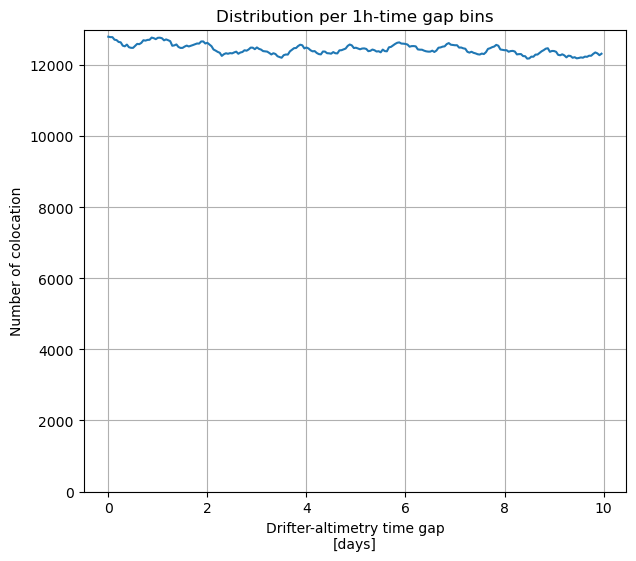

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(7,6))
ds.nb_coloc.plot(ax=ax)
ax.grid()
ax.set_ylabel('Number of colocation')
ax.set_title('Distribution per 1h-time gap bins') 
ax.set_ylim(0, 13000)

__________________
## Pair's contributions

In [12]:
Xn = [k for k in ds.keys() if 'Xn' in k]
Xe = [k for k in ds.keys() if 'Xe' in k]

Xe

['Xe_acc_cor',
 'Xe_acc_ggd',
 'Xe_acc_wd',
 'Xe_cor_ggd',
 'Xe_cor_wd',
 'Xe_ggd_wd']

In [13]:
xstyle = {l.replace('Xn_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in Xn}


Text(0.5, 1.0, 'Total')

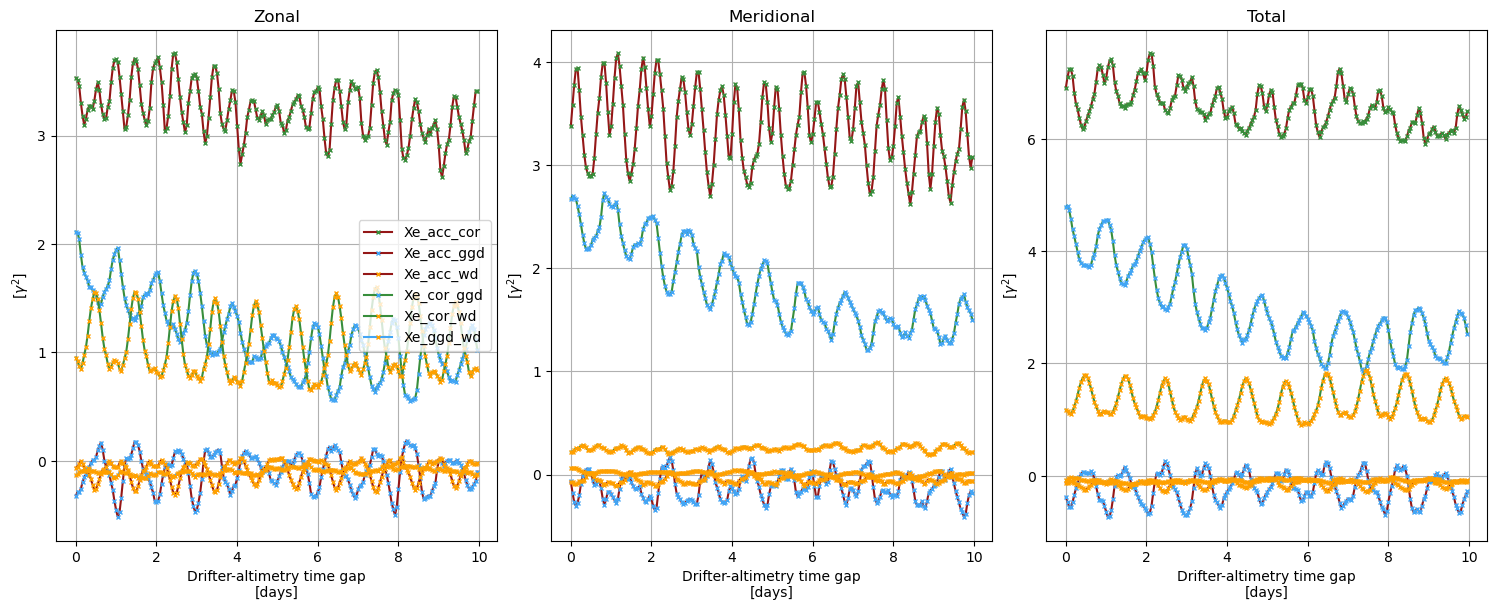

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(15,6))
axs =axs.flatten()
for xn in Xn:
    ds[xn].plot(ax=axs[1], label=xn, **xstyle[xn.replace('Xn_', '')])
for xe in Xe:
    ds[xe].plot(ax=axs[0], label=xe, **xstyle[xe.replace('Xe_', '')])
i=0
for xn in Xn:
    (ds[xn] +ds[Xe[i]]).plot( ax=axs[2], label=xn, **xstyle[xn.replace('Xn_', '')])
    i+=1
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
axs[0].legend()

axs[0].set_title('Zonal')
axs[1].set_title('Meridional')
axs[2].set_title('Total')



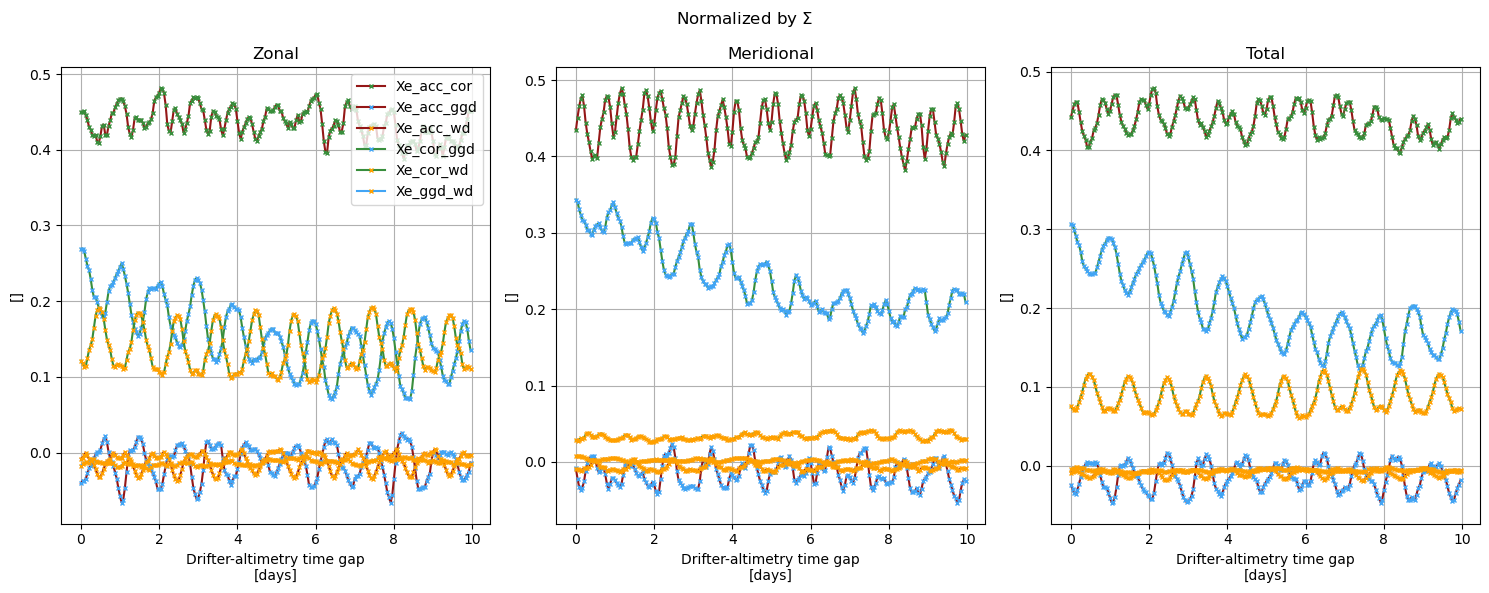

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(15,6))
axs =axs.flatten()
for xn in Xn:
    (ds[xn]/ds.sigman).plot(ax=axs[1], label=xn, **xstyle[xn.replace('Xn_', '')])
for xe in Xe:
    (ds[xe]/ds.sigmae).plot(ax=axs[0], label=xe, **xstyle[xe.replace('Xe_', '')])
i=0
for xn in Xn:
    ((ds[xn]+ds[Xe[i]])/(ds.sigman+ds.sigmae)).plot(ax=axs[2], label=xn, **xstyle[xn.replace('Xn_', '')])
    i+=1
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[]')
    
axs[0].legend()

axs[0].set_title('Zonal')
axs[1].set_title('Meridional')
axs[2].set_title('Total')

fig.suptitle(r'Normalized by $\Sigma$')
fig.tight_layout()

__________________
## Balanced signal contributions

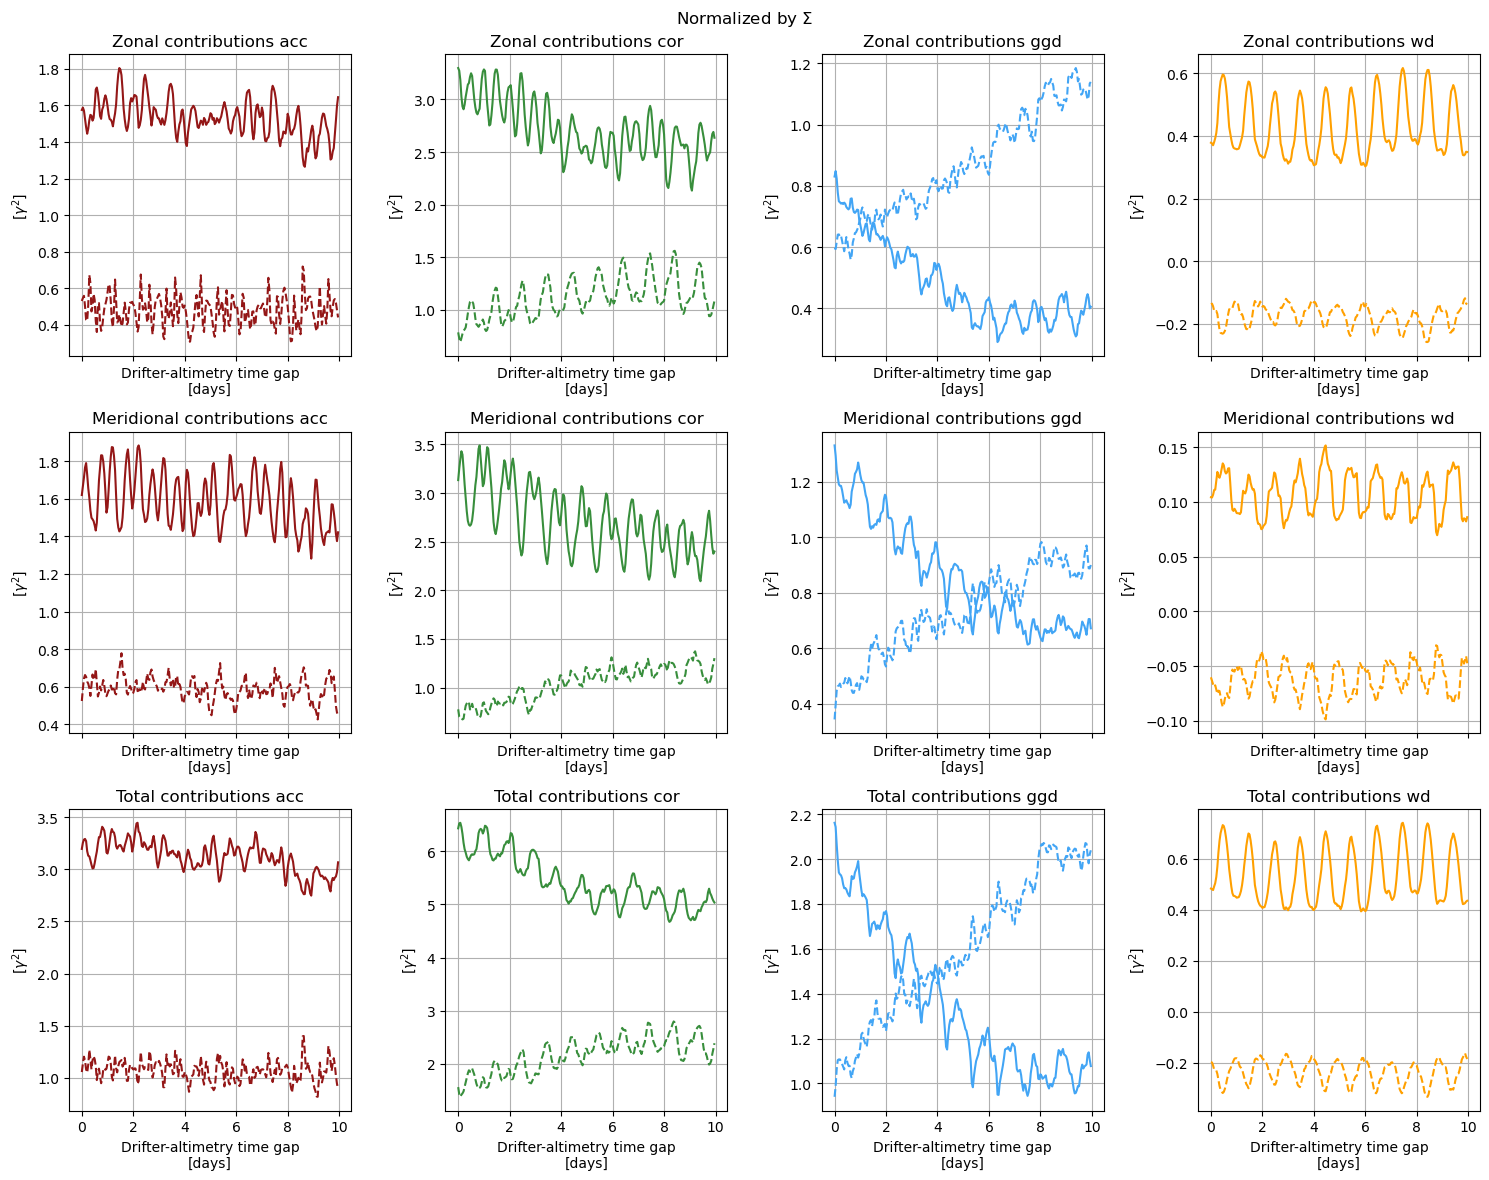

In [21]:
vars = ['acc', 'cor', 'ggd', 'wd']

Bn = [k for k in ds.keys() if 'Bn' in k]
Be = [k for k in ds.keys() if 'Be' in k]

fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True)
axs =axs.flatten()
i=0
for v in vars :
    ax=axs[i]
    ds['Be_'+v].plot(ax=ax, label='Be_'+v, color = c0[v])
    ds['Ee_'+v].plot(ax=ax, label='Ee_'+v, color = c0[v], ls='--')
    i+=1
    ax.set_title('Zonal contributions '+v)

for v in vars :
    ax=axs[i]
    ds['Bn_'+v].plot(ax=ax, label='Bn_'+v, color = c0[v])
    ds['En_'+v].plot(ax=ax, label='En_'+v, color = c0[v], ls='--')
    i+=1
    ax.set_title('Meridional contributions '+v)
    
for v in vars :
    ax=axs[i]
    (ds['Bn_'+v] + ds['Be_'+v]).plot(ax=ax, label='Bn_'+v, color = c0[v])
    (ds['En_'+v]+ds['Ee_'+v]).plot(ax=ax, label='En_'+v, color = c0[v], ls='--')
    i+=1
    ax.set_title('Total contributions '+v)
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')

fig.suptitle(r'Normalized by $\Sigma$')
fig.tight_layout()

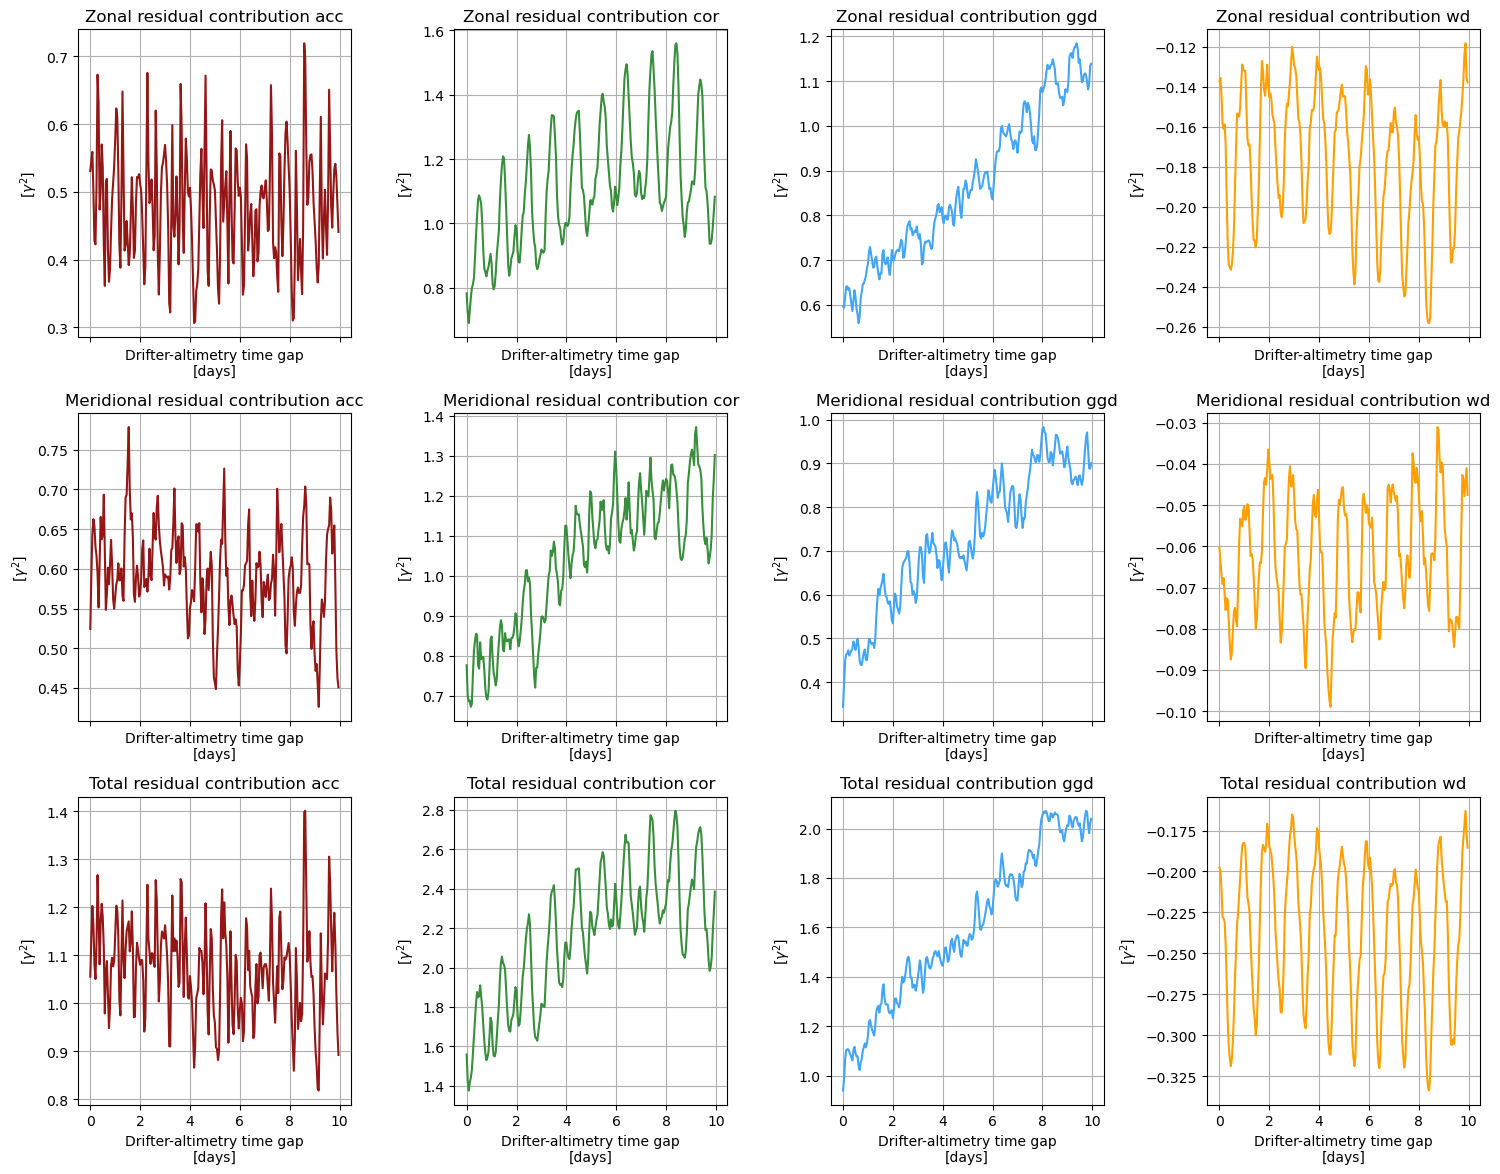

In [22]:
Bn = [k for k in ds.keys() if 'En' in k]
Be = [k for k in ds.keys() if 'Ee' in k]

fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True)
axs =axs.flatten()
i=0
for be in Be:
    ax=axs[i]
    ds[be].plot(ax=ax, label=be, color = c0[be.replace('Ee_', '')])
    i+=1
    ax.set_title('Zonal residual contribution ' + be.replace('Ee_', ''))

for bn in Bn:
    ax=axs[i]
    ds[bn].plot(ax=ax, label=bn, color = c0[bn.replace('En_', '')])
    i+=1
    ax.set_title('Meridional residual contribution ' + bn.replace('En_', ''))
    
for bn in Bn:
    ax=axs[i]
    (ds[bn] +ds[Be[i-8]]).plot(ax=ax, label=bn, color = c0[bn.replace('En_', '')])
    i+=1
    ax.set_title('Total residual contribution ' + bn.replace('En_', ''))
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')

fig.suptitle(r'')
fig.tight_layout()

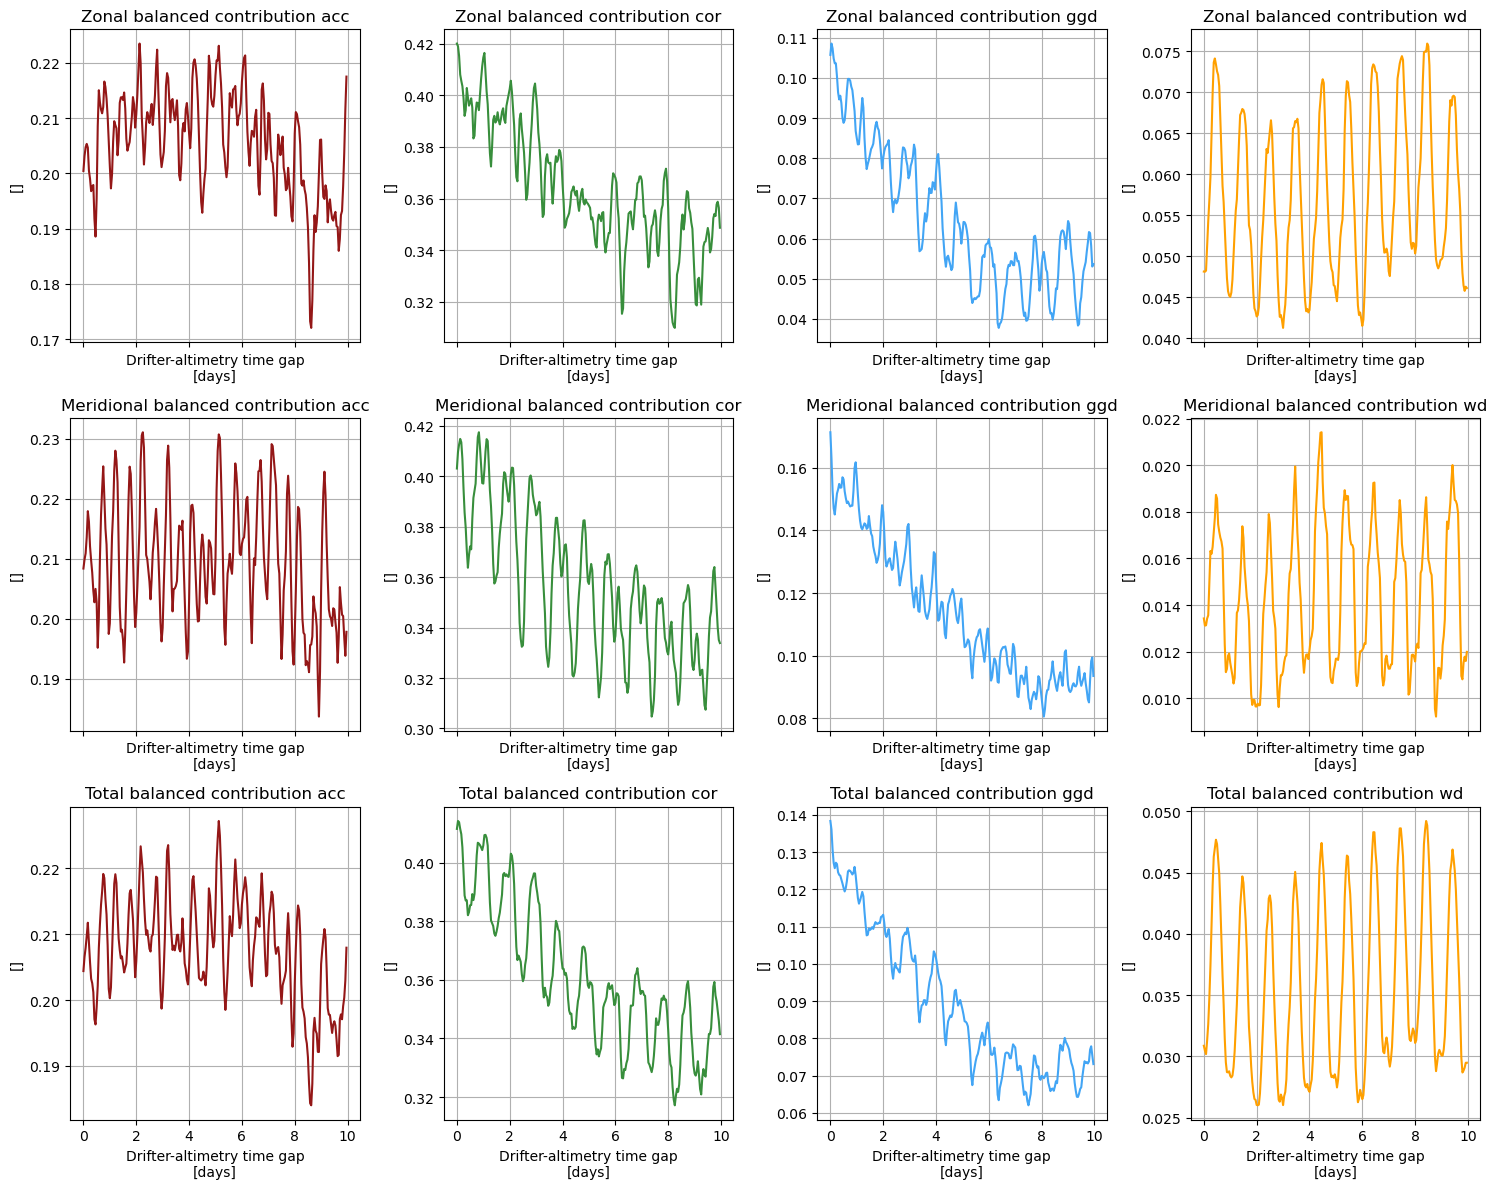

In [85]:
Bn = [k for k in ds.keys() if 'Bn' in k]
Be = [k for k in ds.keys() if 'Be' in k]

fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True)
axs =axs.flatten()
i=0
for be in Be:
    ax=axs[i]
    (ds[be]/ds['sigmae']).plot(ax=ax, label=be, color = c0[be.replace('Be_', '')])
    i+=1
    ax.set_title('Zonal balanced contribution ' + be.replace('Be_', ''))

for bn in Bn:
    ax=axs[i]
    (ds[bn]/ds['sigman']).plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
    i+=1
    ax.set_title('Meridional balanced contribution ' + bn.replace('Bn_', ''))
    
for bn in Bn:
    ax=axs[i]
    ((ds[bn] +ds[Be[i-8]])/(ds['sigman'] + ds['sigmae'])).plot(ax=ax, label=bn, color = c0[bn.replace('Bn_', '')])
    i+=1
    ax.set_title('Total balanced contribution ' + bn.replace('Bn_', ''))
    
fig.tight_layout()
for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[]')
fig.tight_layout()

__________________
## Term variance

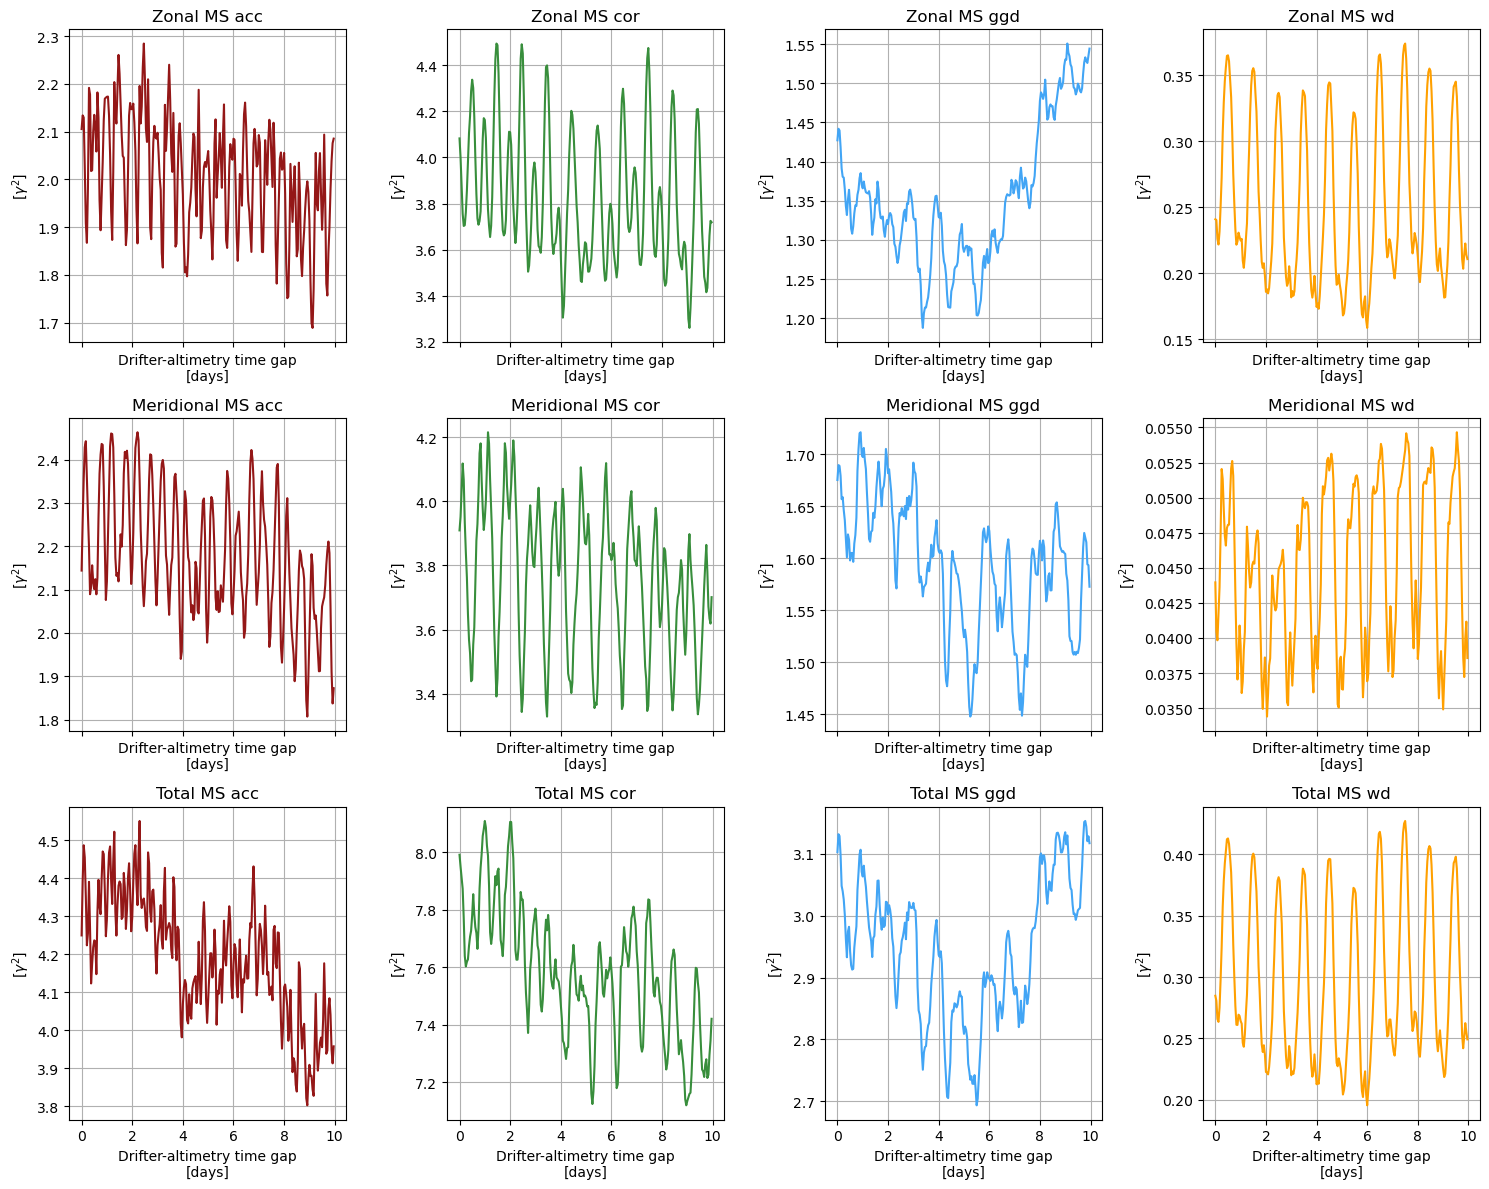

In [86]:
fig, axs = plt.subplots(3, 4, figsize=(15,12), sharex=True)
axs =axs.flatten()
i=0
var = ['acc', 'cor', 'ggd', 'wd']
for v in var :
    ax =axs[i]
    ds[v.upper() +'e'].plot(color=c0[v], ax=ax)
    ax.set_title('Zonal MS ' + v)
    i+=1
for v in var :
    ax =axs[i]
    ds[v.upper() +'n'].plot(color=c0[v],ax=ax)
    ax.set_title('Meridional MS ' + v)
    i+=1

for v in var :
    ax =axs[i]
    (ds[v.upper() +'e'] + ds[v.upper() +'n']).plot(color=c0[v], ax=ax)
    ax.set_title('Total MS ' + v)
    i+=1

for ax in axs:
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    #ax.axvline(0.5, c = 'k', ls=':')
    #ax.axvline(1.5, c = 'k', ls=':')

fig.tight_layout()

In [43]:
ds

<xarray.Dataset> Size: 81kB
Dimensions:          (time_to_swot_1h: 240)
Coordinates:
  * time_to_swot_1h  (time_to_swot_1h) float64 2kB 0.0 0.04167 ... 9.917 9.958
Data variables: (12/41)
    ACCn             (time_to_swot_1h) float64 2kB 2.144 2.257 ... 1.837 1.872
    CORn             (time_to_swot_1h) float64 2kB 3.909 3.952 ... 3.619 3.701
    GGDn             (time_to_swot_1h) float64 2kB 1.675 1.689 ... 1.593 1.573
    WDn              (time_to_swot_1h) float64 2kB 0.04396 0.04045 ... 0.03857
    Sn               (time_to_swot_1h) float64 2kB 1.584 1.62 ... 2.552 2.606
    ACCe             (time_to_swot_1h) float64 2kB 2.105 2.134 ... 2.076 2.085
    ...               ...
    Xn_acc_cor       (time_to_swot_1h) float64 2kB 3.376 3.58 ... 2.975 3.08
    Xn_acc_ggd       (time_to_swot_1h) float64 2kB -0.06521 -0.1738 ... -0.1754
    Xn_acc_wd        (time_to_swot_1h) float64 2kB -0.07188 ... -0.06112
    Xn_cor_ggd       (time_to_swot_1h) float64 2kB 2.669 2.705 ... 1.561 1.502
    Xn_cor_wd        (time_to_swot_1h) float64 2kB 0.2212 0.2216 ... 0.2159
    Xn_ggd_wd        (time_to_swot_1h) float64 2kB 0.05934 0.05985 ... 0.01745

In [63]:
dff_ = dff.reset_index().set_index('time_to_swot').iloc[0,100]

cycle_number  pass_number  drifter_id
482           3            0-4388557     Axes(0.125,0.2;0.775x0.68)
                           0-4388605     Axes(0.125,0.2;0.775x0.68)
                           0-4388627     Axes(0.125,0.2;0.775x0.68)
483           3            0-4351296     Axes(0.125,0.2;0.775x0.68)
                           0-4388554     Axes(0.125,0.2;0.775x0.68)
                           0-4388557     Axes(0.125,0.2;0.775x0.68)
                           0-4388581     Axes(0.125,0.2;0.775x0.68)
                           0-4388599     Axes(0.125,0.2;0.775x0.68)
                           0-4388605     Axes(0.125,0.2;0.775x0.68)
                           0-4388608     Axes(0.125,0.2;0.775x0.68)
                           0-4388627     Axes(0.125,0.2;0.775x0.68)
                           143           Axes(0.125,0.2;0.775x0.68)
                           149           Axes(0.125,0.2;0.775x0.68)
                           3             Axes(0.125,0.2;0.775x0.68)
484       

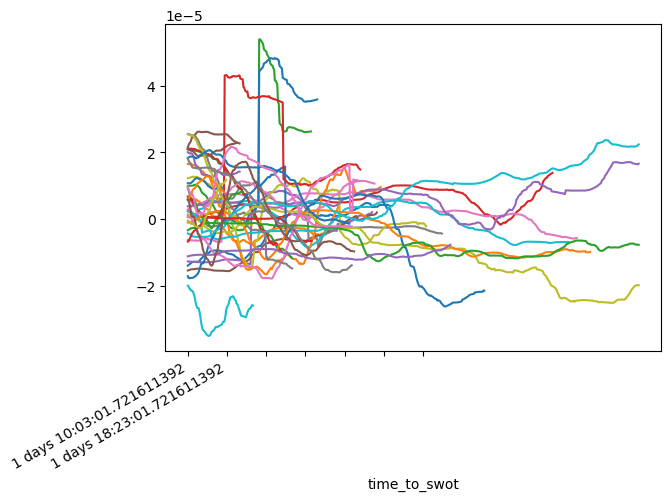

In [68]:
dff_ = dff.iloc[10000:20000]
dff_.groupby(['cycle_number','pass_number', 'drifter_id']).ggde.plot()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_60593/896845535.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dff_ = dff[dff.cycle_number == 500][dff.pass_number == 3][dff.drifter_id == '0-4367707'].set_index('time_to_swot')
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_60593/896845535.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dff_ = dff[dff.cycle_number == 500][dff.pass_number == 3][dff.drifter_id == '0-4367707'].set_index('time_to_swot')


<Axes: xlabel='time_to_swot'>

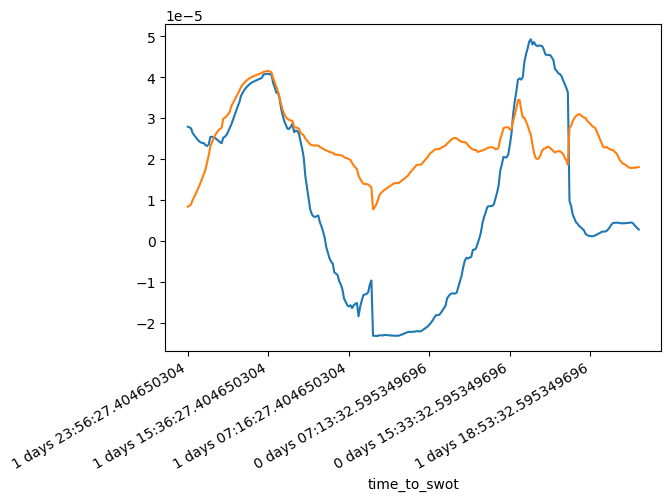

In [58]:
dff_ = dff[dff.cycle_number == 500][dff.pass_number == 3][dff.drifter_id == '0-4367707'].set_index('time_to_swot')
dff_.ggde.plot()
dff_.ggdn.plot()

/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_60593/2169868363.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dff_ = dff[dff.cycle_number == 510][dff.pass_number == 3][dff.drifter_id == '0-4367707'].set_index('time_to_swot')
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_60593/2169868363.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dff_ = dff[dff.cycle_number == 510][dff.pass_number == 3][dff.drifter_id == '0-4367707'].set_index('time_to_swot')


<Axes: xlabel='time_to_swot'>

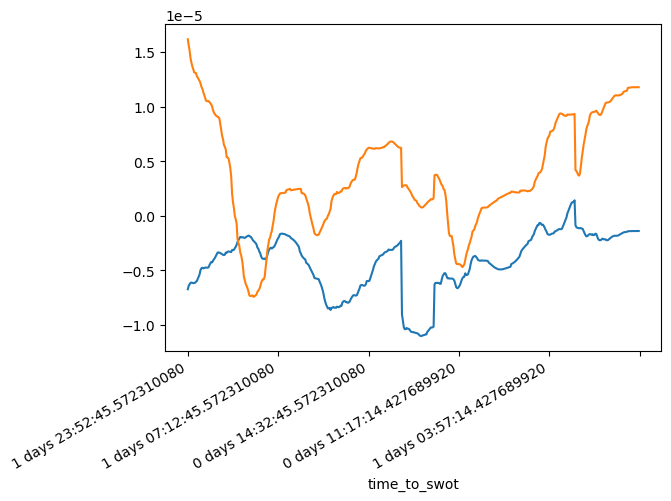

In [60]:
dff_ = dff[dff.cycle_number == 510][dff.pass_number == 3][dff.drifter_id == '0-4367707'].set_index('time_to_swot')
dff_.ggde.plot()
dff_.ggdn.plot()

In [63]:
dff

,id_comb,sume,acce,exce_acc,core,exce_cor,ggde,exce_ggd,wde,exce_wd,...,longitude,latitude,pass_number,time_to_swot,cycle_number,drifter_id,drifter_type,depth,time_to_swot_1h,time_to_swot_d
row_number,,,,,,,,,,,,,,,,,,,,,
77,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000005,0.000013,-0.000019,-0.000015,0.000009,-0.000003,-0.000003,-1.183162e-06,-0.000004,...,4.132502,40.409746,3,3 days 14:17:27.303464,478,0-4388608,CARTHE,0,86.0,3.595455
78,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000005,0.000014,-0.000019,-0.000015,0.000010,-0.000003,-0.000003,-1.127788e-06,-0.000004,...,4.133124,40.410612,3,3 days 14:27:27.303464,478,0-4388608,CARTHE,0,86.0,3.602399
79,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000005,0.000014,-0.000020,-0.000016,0.000010,-0.000003,-0.000003,-1.072328e-06,-0.000004,...,4.133804,40.411515,3,3 days 14:37:27.303464,478,0-4388608,CARTHE,0,86.0,3.609344
80,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000005,0.000015,-0.000020,-0.000017,0.000011,-0.000003,-0.000003,-1.016762e-06,-0.000004,...,4.134544,40.412458,3,3 days 14:47:27.303464,478,0-4388608,CARTHE,0,86.0,3.616288
81,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000005,0.000016,-0.000021,-0.000017,0.000012,-0.000003,-0.000002,-9.610663e-07,-0.000004,...,4.135347,40.413440,3,3 days 14:57:27.303464,478,0-4388608,CARTHE,0,86.0,3.623233
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7480901,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000003,-0.000026,0.000022,0.000033,-0.000036,-0.000010,0.000007,-1.134655e-07,-0.000003,...,1.090200,40.578007,16,3 days 15:56:21.868455616,577,4694474,CARTHE,0,87.0,3.664142
7480902,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000004,-0.000027,0.000023,0.000033,-0.000037,-0.000010,0.000006,-1.138796e-07,-0.000004,...,1.090445,40.576131,16,3 days 15:46:21.868455616,577,4694474,CARTHE,0,87.0,3.657198
7480903,nofilter__swot2kmnaive_etaf__rio_0era5,-0.000004,-0.000028,0.000024,0.000034,-0.000038,-0.000010,0.000006,-1.142896e-07,-0.000004,...,1.090577,40.574212,16,3 days 15:36:21.868455616,577,4694474,CARTHE,0,87.0,3.650253


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_71141/2699093505.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dff_ = dff[dff.pass_number == 3][dff.cycle_number == 500].set_index('time_to_swot_d')
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_71141/2699093505.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(1, 2)


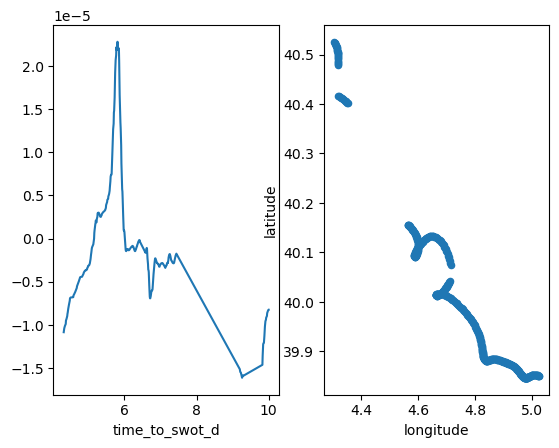

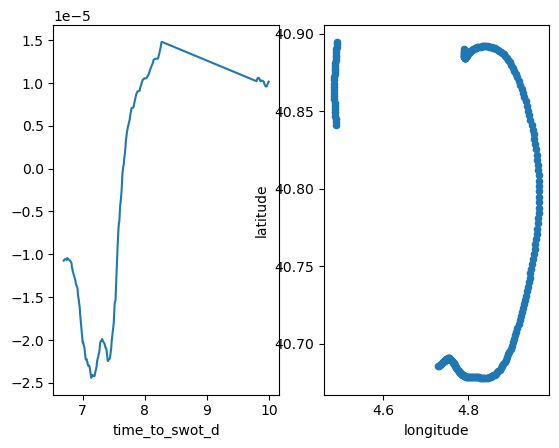

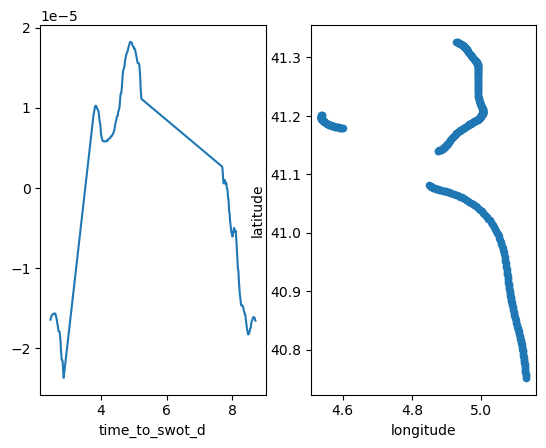

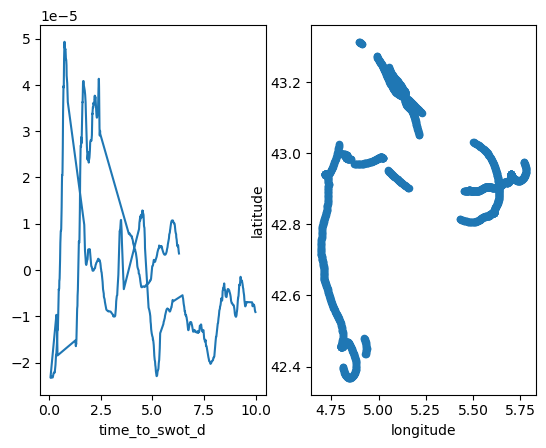

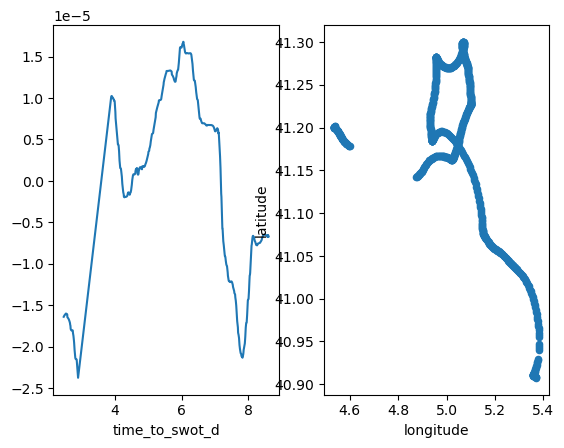

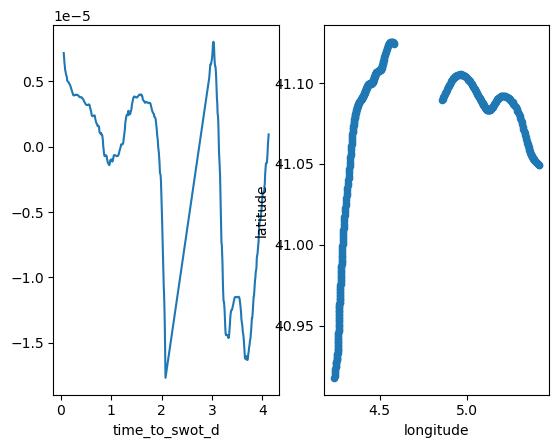

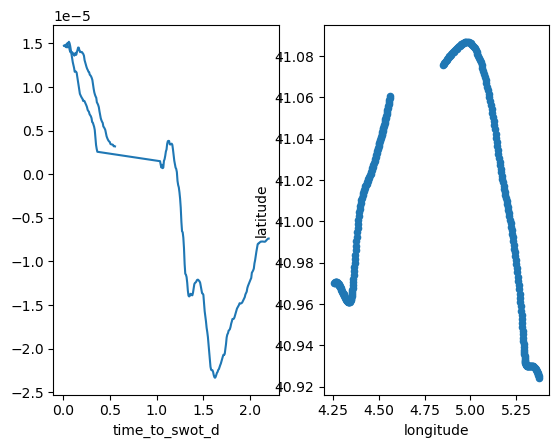

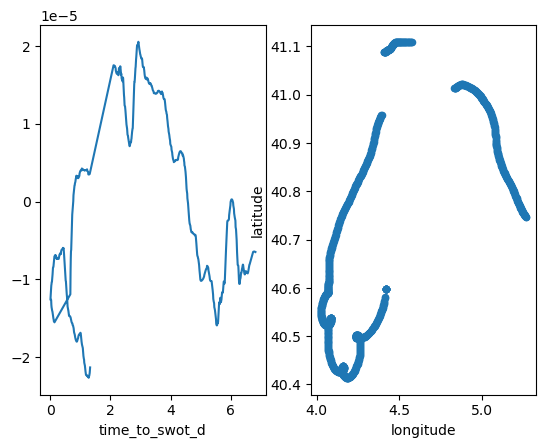

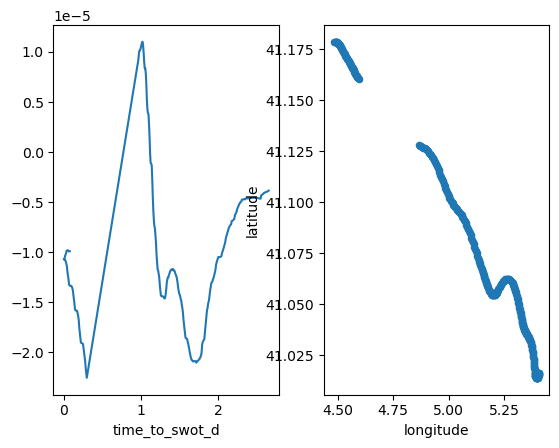

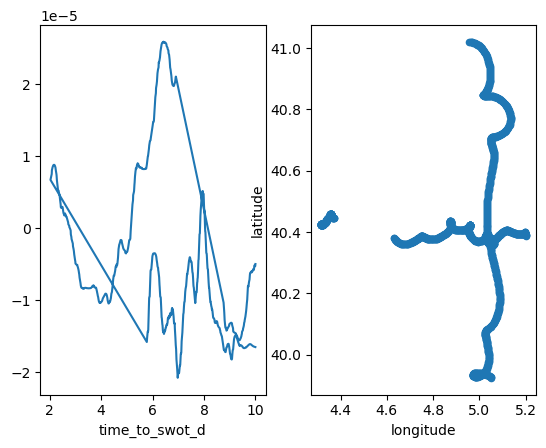

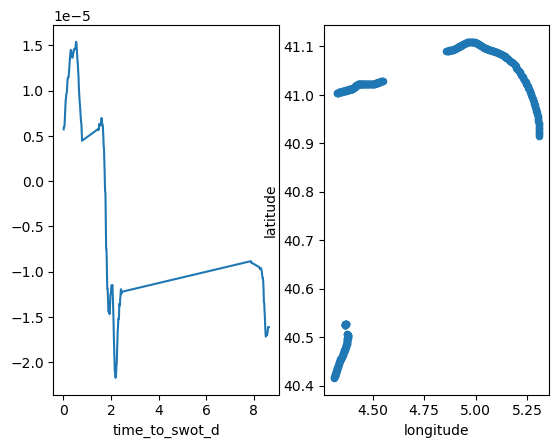

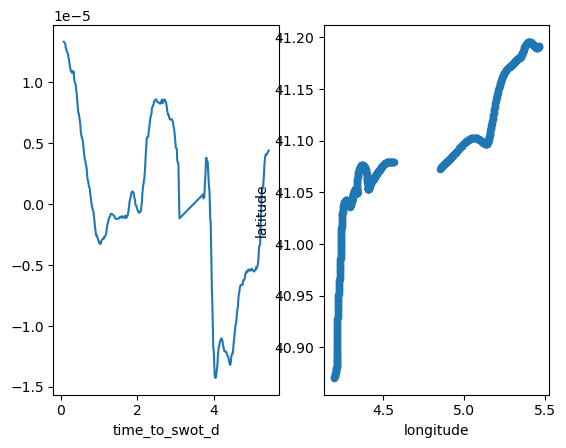

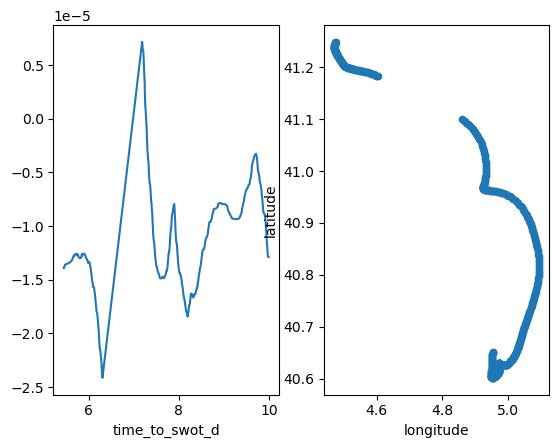

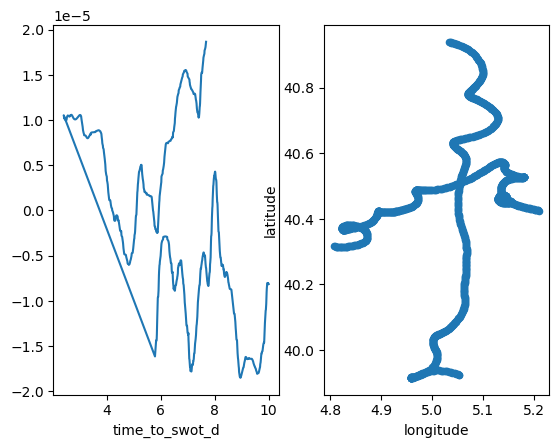

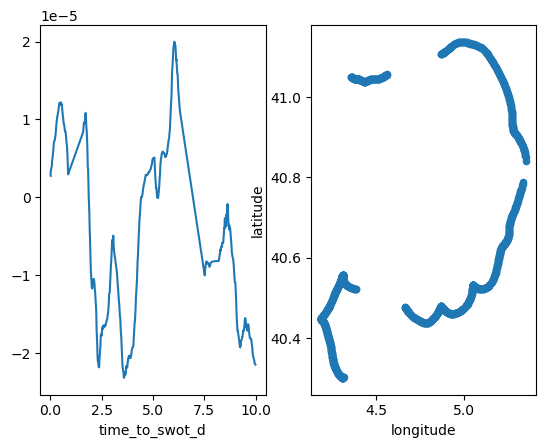

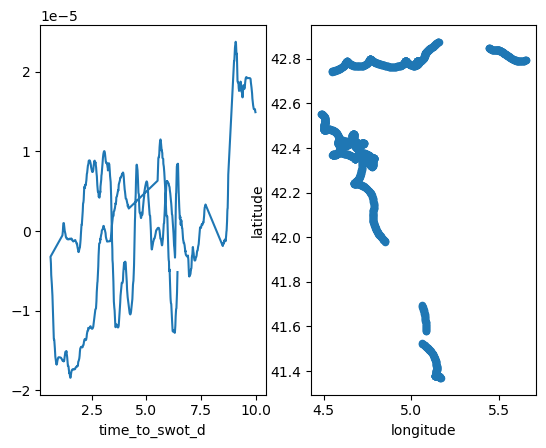

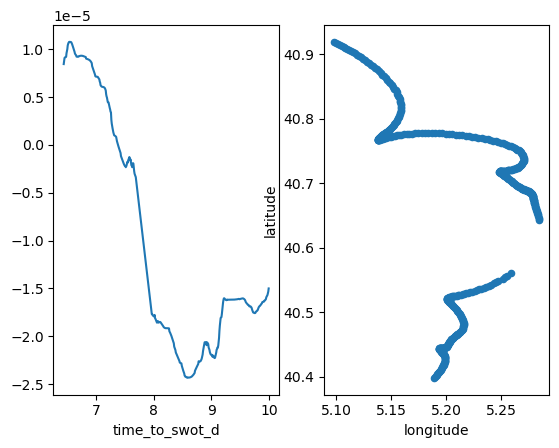

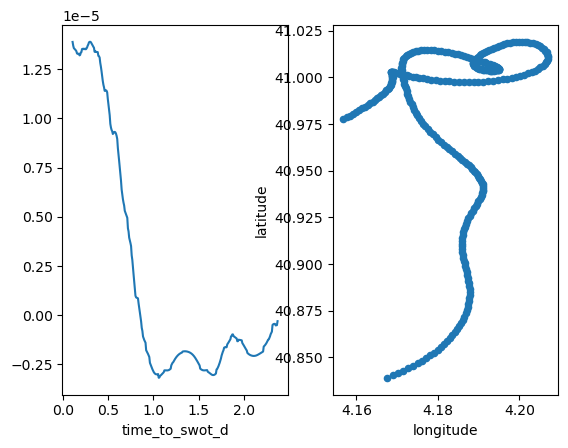

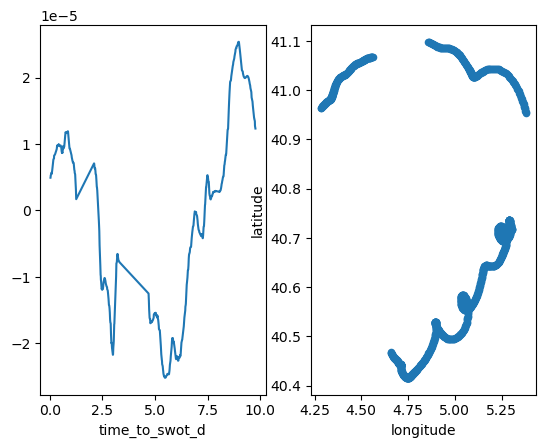

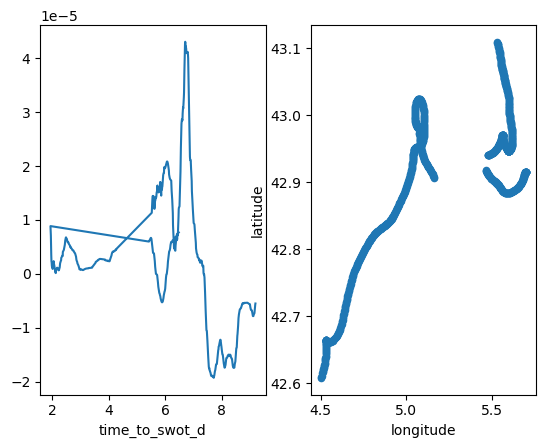

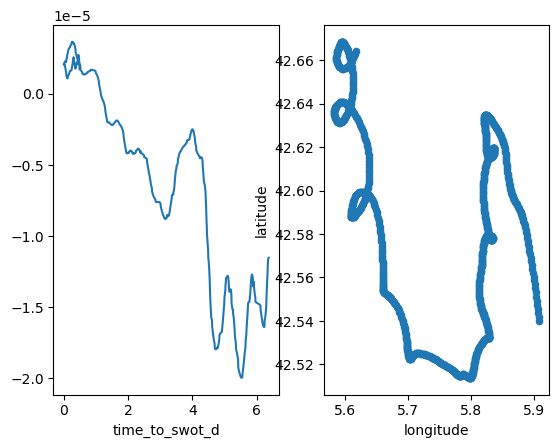

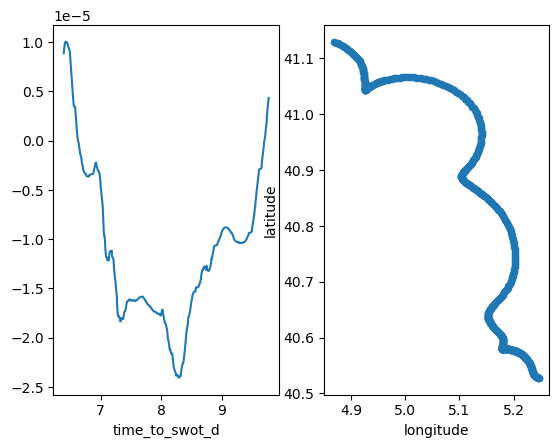

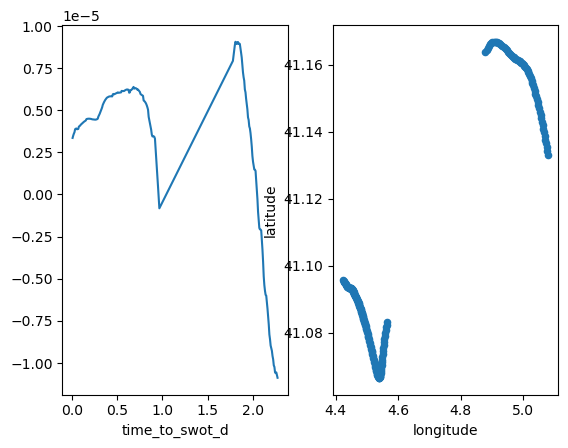

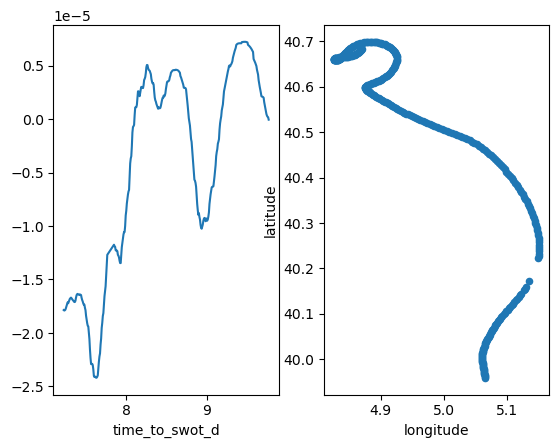

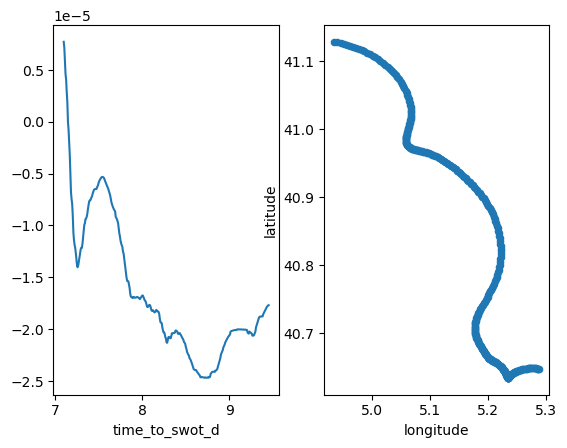

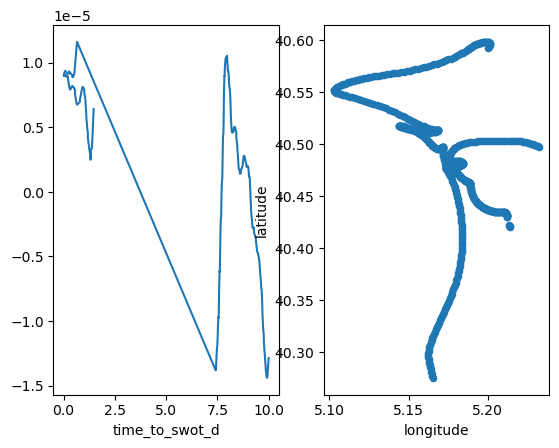

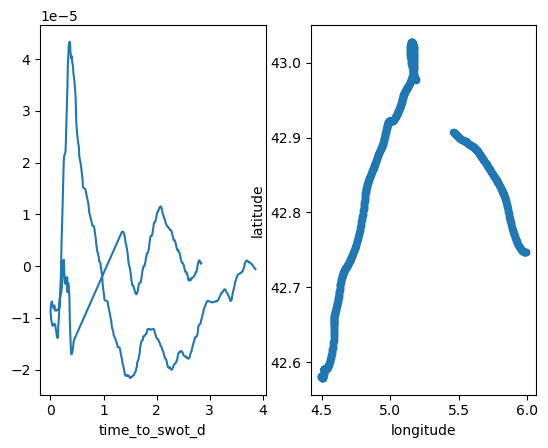

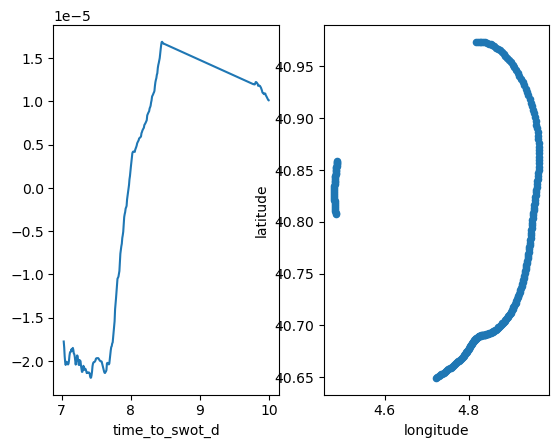

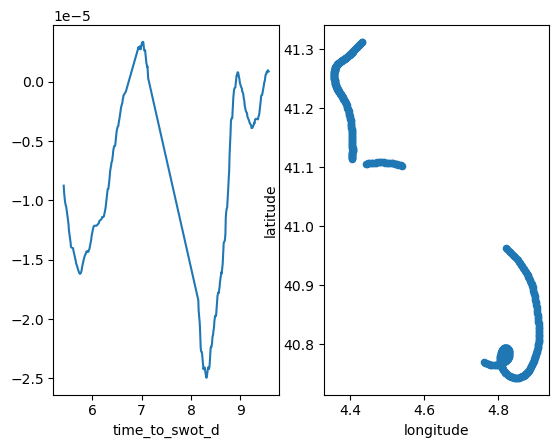

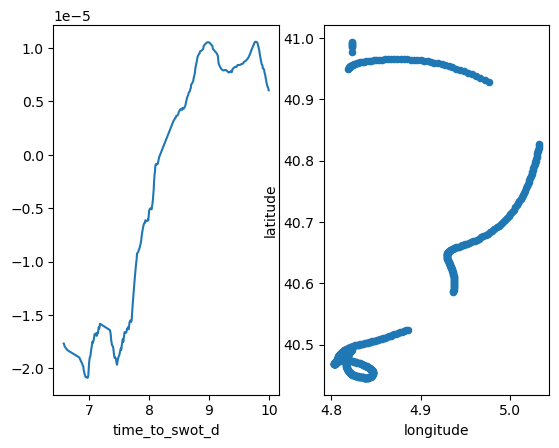

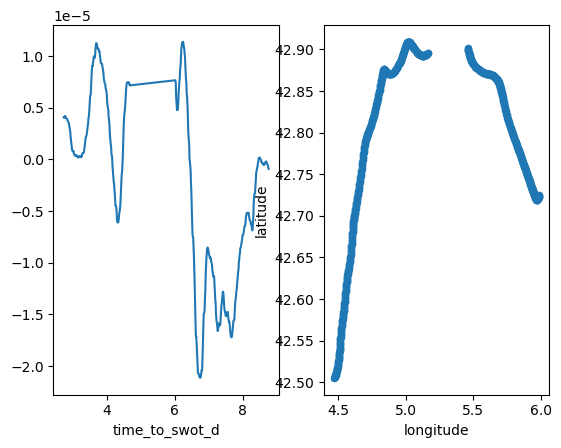

In [64]:
passn =3
cycle = np.random.randint(479, 577, 1)
dff['time_to_swot_d'] = dff['time_to_swot']/pd.Timedelta('1d')
dff_ = dff[dff.pass_number == 3][dff.cycle_number == 500].set_index('time_to_swot_d')
drift = dff_.drifter_id.unique()

for d in drift : 
    fig, axs = plt.subplots(1, 2)
    dff_[dff_.drifter_id == d].ggde.plot(ax=axs[0])
    dff_[dff_.drifter_id == d].plot.scatter(x='longitude', y='latitude',ax=axs[1])

In [46]:
dss_ = DSS.isel(row_number = np.random.randint(0, 2e4, 10))

In [47]:
dss_.ggde.plot(hue = 'row_number')

<xarray.Dataset> Size: 4kB
Dimensions:          (id_comb: 1, row_number: 10)
Coordinates:
    datetime         (id_comb, row_number) datetime64[ns] 80B 2023-04-11T01:3...
    longitude        (id_comb, row_number) float64 80B 4.539 4.673 ... 5.583
    latitude         (id_comb, row_number) float64 80B 41.46 40.52 ... 42.72
    pass_number      (id_comb, row_number) int64 80B 3 3 3 3 3 3 3 3 3 3
    time_to_swot     (id_comb, row_number) timedelta64[ns] 80B 8 days 01:56:4...
    cycle_number     (id_comb, row_number) int64 80B 479 478 479 ... 479 478 479
    drifter_id       (id_comb, row_number) <U9 360B '0-4388620' ... '0-4388557'
    drifter_type     (id_comb, row_number) <U7 280B 'CARTHE' ... 'CARTHE'
    depth            (id_comb, row_number) int64 80B 0 0 0 0 0 0 0 0 0 0
  * row_number       (row_number) int64 80B 43191 22050 38442 ... 20553 50220
  * id_comb          (id_comb) <U38 152B 'nofilter__swot2kmnaive_etaf__rio_0e...
Data variables: (12/31)
    sume             (id_comb, row_number) float64 80B 1.31e-05 ... 1.361e-05
    acce             (id_comb, row_number) float64 80B 8.057e-06 ... 1.925e-05
    exce_acc         (id_comb, row_number) float64 80B 5.042e-06 ... -5.648e-06
    core             (id_comb, row_number) float64 80B 4.462e-06 ... 8.516e-06
    exce_cor         (id_comb, row_number) float64 80B 8.637e-06 ... 5.091e-06
    ggde             (id_comb, row_number) float64 80B 8.562e-07 ... 2.753e-06
    ...               ...
    prodn_acc_ggd    (id_comb, row_number) float64 80B 2.678e-12 ... 2.308e-11
    prodn_acc_wd     (id_comb, row_number) float64 80B -3.573e-13 ... -8.724e-11
    prodn_cor_ggd    (id_comb, row_number) float64 80B 1.093e-10 ... 2.186e-11
    prodn_cor_wd     (id_comb, row_number) float64 80B -1.458e-11 ... -8.263e-11
    prodn_ggd_wd     (id_comb, row_number) float64 80B -1.252e-11 ... -1.487e-11
    time_to_swot_1h  (id_comb, row_number) float64 80B 193.0 144.0 ... 104.0 9.0

In [11]:
a = DS.time_to_swot.astype('timedelta64[ns]') 
a.where(a/pd.Timedelta('1h') > 13, drop=True)

<xarray.DataArray 'time_to_swot' (id_comb: 1, row_number: 19366)> Size: 155kB
array([['0 days 13:05:26.278617920', '0 days 13:15:26.278617920',
        '0 days 13:25:26.278617920', ..., '0 days 13:29:51.131302592',
        '0 days 13:19:51.131302592', '0 days 13:09:51.131302592']],
      dtype=object)
Coordinates:
    datetime      (id_comb, row_number) datetime64[ns] 155kB 2023-04-21T09:50...
    longitude     (id_comb, row_number) float64 155kB 4.857 4.857 ... 2.231 2.23
    latitude      (id_comb, row_number) float64 155kB 40.13 40.13 ... 38.65
    pass_number   (id_comb, row_number) int64 155kB 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot  (id_comb, row_number) object 155kB '0 days 13:05:26.2786179...
    cycle_number  (id_comb, row_number) int64 155kB 497 497 497 ... 535 535 535
    drifter_id    (id_comb, row_number) object 155kB '300534060113380' ... '4...
    drifter_type  (id_comb, row_number) object 155kB 'SVP' 'SVP' ... 'CARTHE'
    depth         (id_comb, row_number) int64 155kB 50 50 50 50 50 ... 0 0 0 0 0
  * row_number    (row_number) int64 155kB 47119 47120 47121 ... 330121 330122
  * id_comb       (id_comb) <U38 152B 'nofilter__swot2kmnaive_etaf__rio_0era5'

In [7]:
DS.time_to_swot/pd.Timedelta('1h')

<xarray.DataArray 'time_to_swot' (id_comb: 1, row_number: 290395)> Size: 2MB
array([[11.87574904, 11.70908237, 11.5424157 , ..., 11.5605921 ,
        11.72725876, 11.89392543]])
Coordinates:
    datetime      (id_comb, row_number) datetime64[ns] 2MB 2023-04-01T11:50:0...
    longitude     (id_comb, row_number) float64 2MB 4.812 4.812 ... 2.415 2.414
    latitude      (id_comb, row_number) float64 2MB 42.22 42.22 ... 39.79 39.79
    pass_number   (id_comb, row_number) int64 2MB 3 3 3 3 3 3 ... 16 16 16 16 16
    time_to_swot  (id_comb, row_number) object 2MB '0 days 11:52:32.696536' ....
    cycle_number  (id_comb, row_number) int64 2MB 478 478 478 ... 577 577 577
    drifter_id    (id_comb, row_number) object 2MB '300534060315840' ... '300...
    drifter_type  (id_comb, row_number) object 2MB 'SVP' 'SVP' ... 'SVP' 'SVP'
    depth         (id_comb, row_number) int64 2MB 15 15 15 15 15 ... 15 15 15 15
  * row_number    (row_number) int64 2MB 0 1 2 3 ... 383259 383260 383261 383262
  * id_comb       (id_comb) <U38 152B 'nofilter__swot2kmnaive_etaf__rio_0era5'